In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("../data/cleaned_superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136
1,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
2,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
4,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656


## Line Chart

### Monthly Sales Trend using Matplotlib

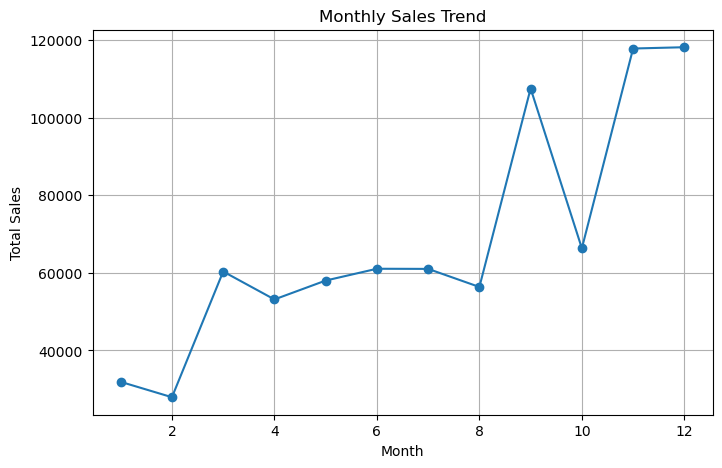

In [4]:
# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Extract Month
df["Month"] = df["Order Date"].dt.month

# Monthly Sales
monthly_sales = df.groupby("Month")["Sales"].sum()

# Create Plot
plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)

# Save as PNG (required by the PDF)
plt.savefig("../dashboards/monthly_sales_trend.png")

# Display the plot
plt.show()

### Observation

The line chart shows the monthly sales trend. Sales fluctuate throughout the year, with higher sales observed during some months.

## Bar Chart

### Total Sales by Category using Matplotlib

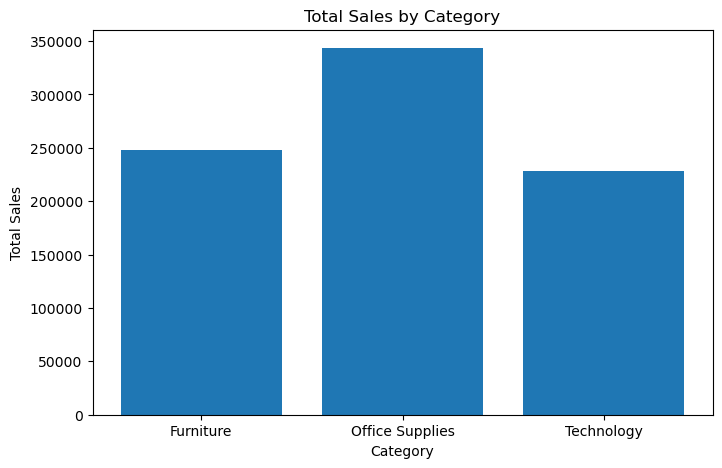

In [7]:
# Sales by Category
category_sales = df.groupby("Category")["Sales"].sum()

# Create Bar Chart
plt.figure(figsize=(8,5))
plt.bar(category_sales.index, category_sales.values)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

# Save as PNG
plt.savefig("../dashboards/category_sales_bar.png")

# Show Plot
plt.show()

### Observation

The bar chart compares total sales across different product categories. It helps identify which category contributes the highest sales.

## Scatter Plot

### Sales vs Profit using Matplotlib

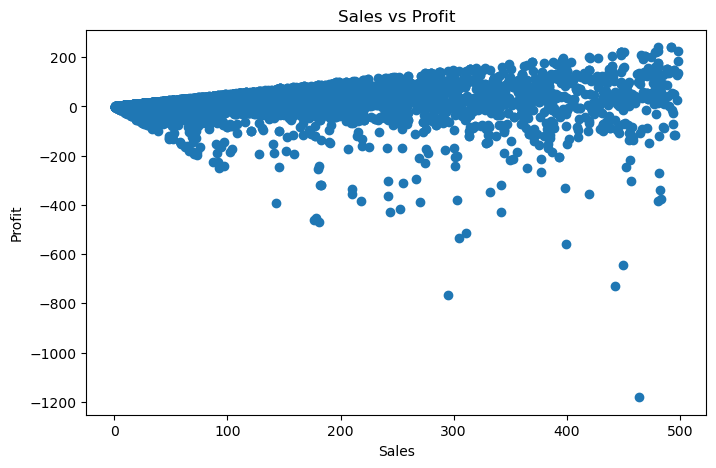

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df["Sales"], df["Profit"])

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

# Save as PNG
plt.savefig("../dashboards/sales_vs_profit_scatter.png")

# Show Plot
plt.show()

### Observation

The scatter plot shows the relationship between sales and profit. It helps identify profitable and loss-making transactions.

## Histogram

### Distribution of Sales using Matplotlib

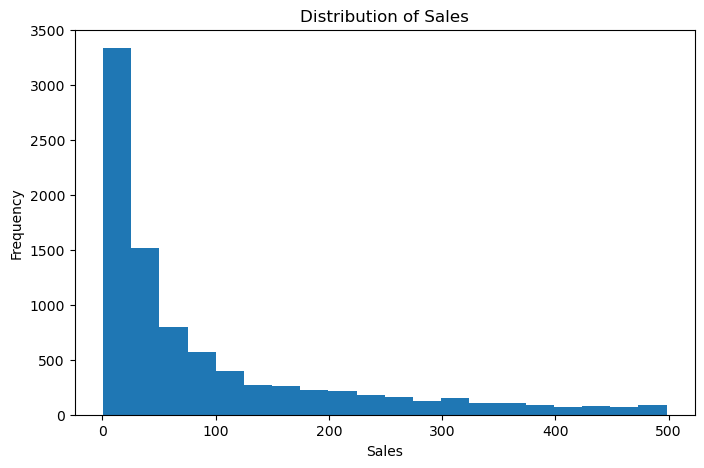

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=20)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

# Save as PNG
plt.savefig("../dashboards/sales_histogram.png")

# Show Plot
plt.show()

### Observation

The histogram shows the distribution of sales values. Most orders have lower sales, while a smaller number of orders have very high sales.

## Heatmap

### Correlation Matrix using Seaborn

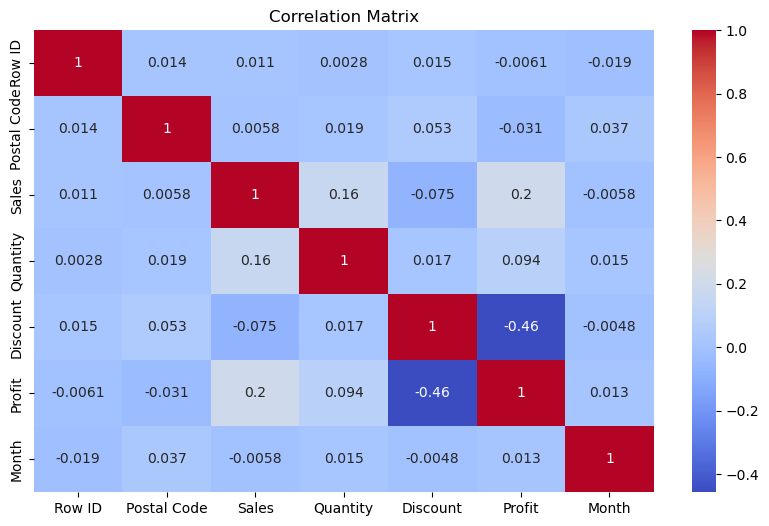

In [11]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Create Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

# Save as PNG
plt.savefig("../dashboards/correlation_heatmap.png")

plt.show()

### Observation

The heatmap displays the correlation between numeric variables. It helps identify positive and negative relationships among features.

## Pairplot

### Pairwise Relationship using Seaborn

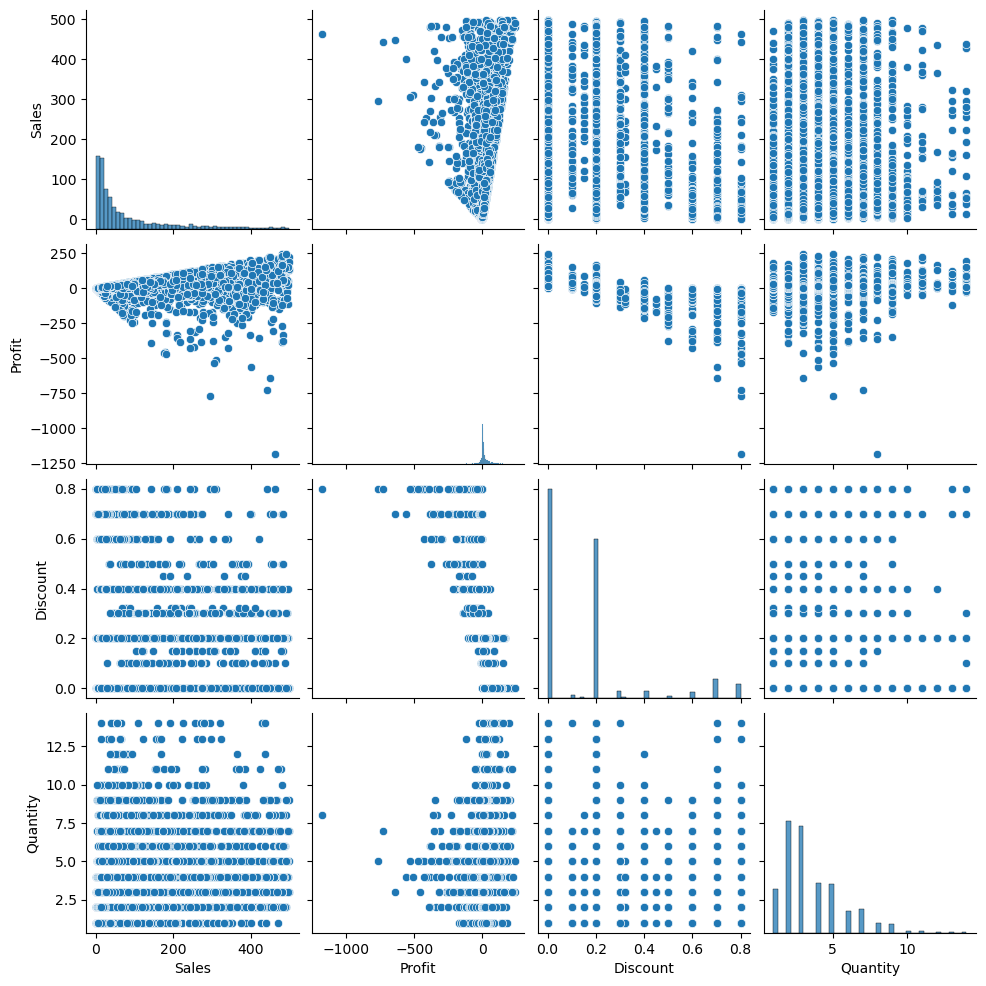

In [14]:
# Pairplot of selected numeric columns
pair_plot = sns.pairplot(
    df[["Sales", "Profit", "Discount", "Quantity"]]
)

# Save as PNG
pair_plot.savefig("../dashboards/pairplot.png")

plt.show()

### Observation

The pairplot shows pairwise relationships and distributions of Sales, Profit, Discount, and Quantity.

## Boxen Plot

### Sales Distribution by Category

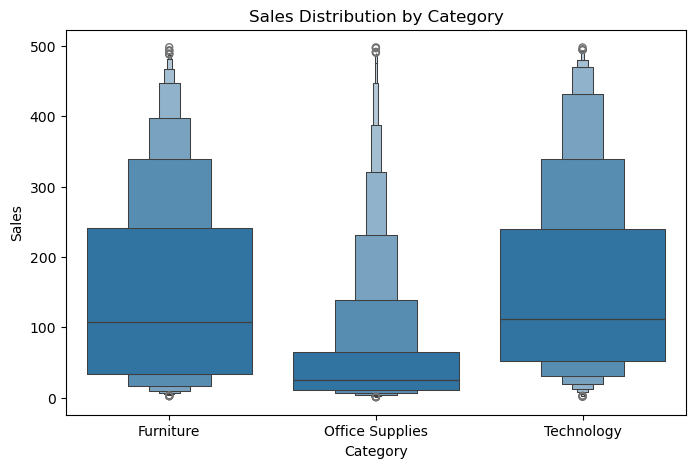

In [15]:
plt.figure(figsize=(8,5))

sns.boxenplot(
    x="Category",
    y="Sales",
    data=df
)

plt.title("Sales Distribution by Category")

# Save as PNG
plt.savefig("../dashboards/boxenplot_sales_category.png")

plt.show()

### Observation

The boxen plot compares the sales distribution across categories and highlights variation and potential outliers.

## Interactive Bar Chart

### Total Sales by Category using Plotly

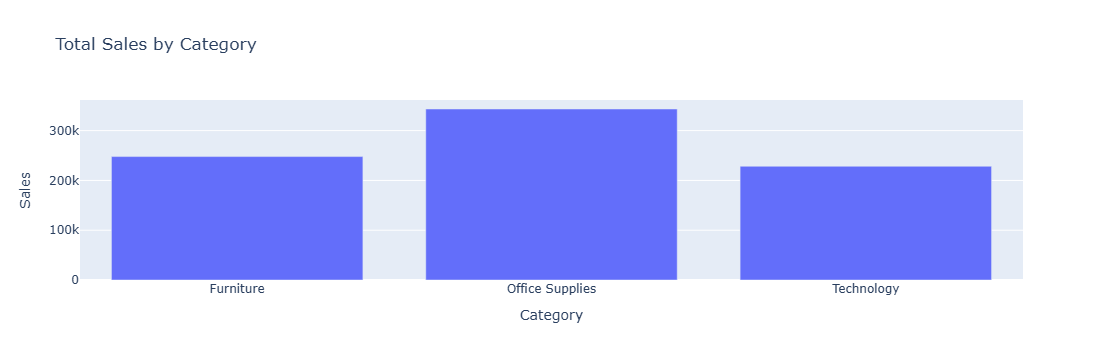

In [17]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .reset_index()
)

fig = px.bar(
    category_sales,
    x="Category",
    y="Sales",
    title="Total Sales by Category"
)

fig.show()

fig.write_html("../dashboards/category_sales_plotly.html")

### Observation

The interactive bar chart allows users to zoom, hover, and explore sales across different product categories.

## Interactive Scatter Plot

### Sales vs Profit using Plotly

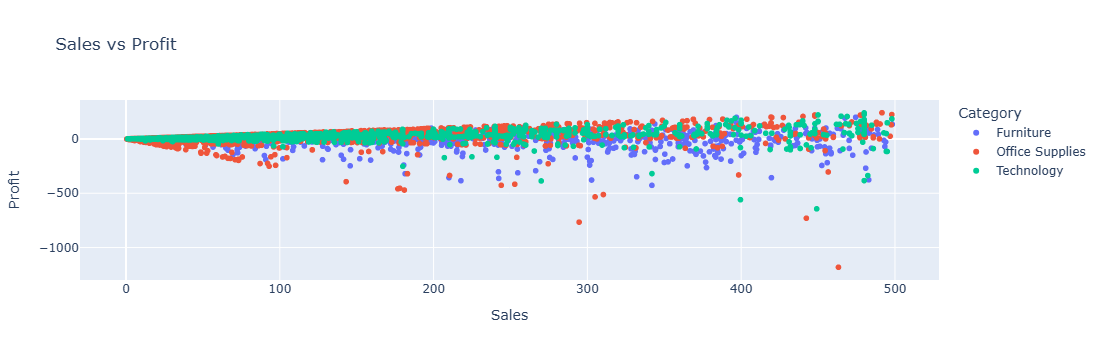

In [18]:
fig = px.scatter(
    df,
    x="Sales",
    y="Profit",
    color="Category",
    title="Sales vs Profit"
)

fig.show()

fig.write_html("../dashboards/sales_profit_plotly.html")

### Observation

The interactive scatter plot helps analyze the relationship between sales and profit while distinguishing product categories using different colors.